# Which Bootstrap \U0001F97E
### A 95% confidence interval is a promise. Does yours keep it?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

Resampling is the most democratic tool in statistics: no formulas, no distributional
assumptions, just draw your data again and see how much the answer wobbles. But there are four
common ways to do the drawing, every backtest picks one without comment, and they do not agree.
This notebook checks which of them actually delivers the 95% it advertises.

> \U0001F4D3 **This is the plain-language layer.** The coverage simulations and the block-length
> sweeps are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do the four bootstraps give the same interval? | No — on the same data they differ in width by tens of percent. |
| Does any of them actually deliver 95%? | On independent data, all. On realistic data, none exactly; some are much closer than others. |
| Which fails worst? | The i.i.d. resample, the one in every tutorial, when returns are genuinely correlated. |
| Does it change conclusions? | On a long sample, rarely. On a three-year backtest, yes — that is where these intervals live. |

## 1 · The claim

> *"Bootstrap it. Resample the returns a few thousand times, take the 2.5th and 97.5th
> percentiles, and you have an honest confidence interval without assuming normality."*

The first sentence is right. The second hides a decision: *resample what, exactly?* Individual
days? Blocks of days? Blocks of random length? Each answer encodes a different belief about
what is independent in your data.

## 2 · So what?

The interval is what turns "my backtest made 8% a year" into "and here is the range I would
defend". If it is systematically too narrow, every strategy on the desk looks more certain
than it is — and the errors all point the same way, because a too-narrow interval never
accidentally makes you cautious.

In [2]:
from boot_choice import data, strategy as st

px = data.load_prices()
rets = {tk: px[tk].dropna().pct_change().dropna() for tk in data.TICKERS}
print(f"as-of {data.AS_OF}")
for tk, r in rets.items():
    p = st.dependence_profile(r)
    print(f"  {tk:8s} n={p['n']:6,}  AR(1) {p['ar1']:+.3f}  |r| AR(1) {p['abs_ar1']:+.3f}  "
          f"excess kurtosis {p['kurtosis']:.1f}")

as-of 2026-06-30
  SPY      n= 8,410  AR(1) -0.082  |r| AR(1) +0.275  excess kurtosis 11.8
  TLT      n= 6,017  AR(1) -0.029  |r| AR(1) +0.228  excess kurtosis 3.5
  GLD      n= 5,435  AR(1) -0.013  |r| AR(1) +0.138  excess kurtosis 6.6
  BTC-USD  n= 4,304  AR(1) -0.023  |r| AR(1) +0.211  excess kurtosis 7.9


Look at the two autocorrelation columns above. Returns themselves are barely correlated — that
is the efficient-market part. But *absolute* returns are strongly correlated: quiet days follow
quiet days. That is the dependence a bootstrap has to respect.

## 3 · How would we even know?

You cannot check a confidence interval on real data, because you never learn the truth. So we
build a world where the true mean and the true Sharpe are known by construction, draw hundreds
of samples from it, build an interval each time, and count.

## 4 · The teardown

### 4.1 What each resample actually does

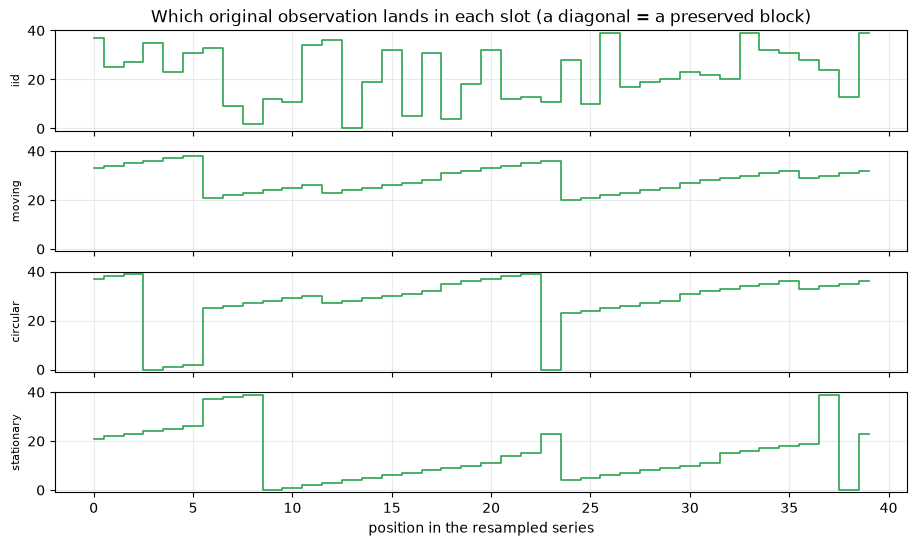

In [3]:
rng = np.random.default_rng(4)
demo = np.arange(40)
fig, axes = plt.subplots(4, 1, figsize=(11, 6), sharex=True)
for ax, m in zip(axes, st.METHODS):
    idx = st._resample_indices(40, m, 6, np.random.default_rng(7))
    ax.step(range(40), idx, where="mid", lw=1.2, color="#2ea44f")
    ax.set_ylabel(m, fontsize=8)
    ax.set_ylim(-1, 40)
axes[-1].set_xlabel("position in the resampled series")
axes[0].set_title("Which original observation lands in each slot (a diagonal = a preserved block)")
plt.show()

Diagonal runs are preserved history. The i.i.d. panel has none: it shreds the calendar
completely, which is fine if nothing depends on anything, and fatal otherwise.

### 4.2 Coverage, where the truth is known

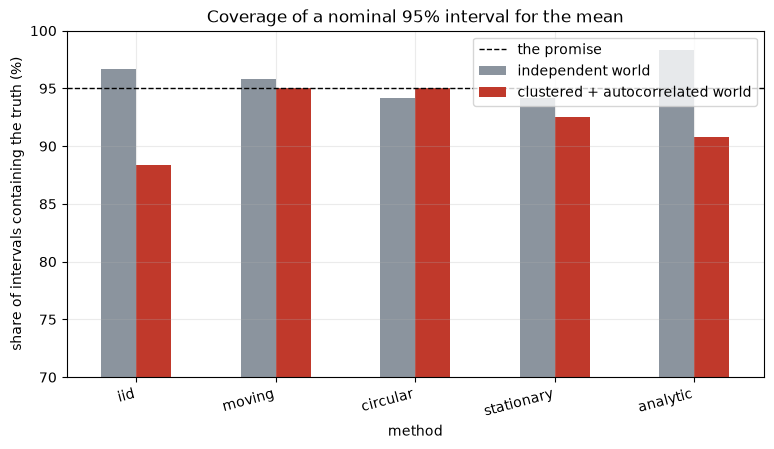

,independent world,clustered + autocorrelated world
method,,
iid,0.9670,0.8830
moving,0.9580,0.9500
circular,0.9420,0.9500
stationary,0.9420,0.9250
analytic,0.9830,0.9080


In [4]:
def sampler_iid(seed):
    return data.synthetic_returns(n_years=5, ar1=0.0, signal_strength=0.0, seed=seed)

def sampler_dep(seed):
    return data.synthetic_returns(n_years=5, ar1=0.25, signal_strength=1.0, seed=seed)

cov_iid = st.coverage_experiment(sampler_iid, "mu_daily", "mean", n_reps=120, n_boot=250)
cov_dep = st.coverage_experiment(sampler_dep, "mu_daily", "mean", n_reps=120, n_boot=250)
comp = pd.DataFrame({"independent world": cov_iid["coverage"],
                     "clustered + autocorrelated world": cov_dep["coverage"]})
fig, ax = plt.subplots(figsize=(9, 4.5))
comp.mul(100).plot.bar(ax=ax, color=["#8b949e", "#c0392b"])
ax.axhline(95, color="k", ls="--", lw=1, label="the promise")
ax.set_ylabel("share of intervals containing the truth (%)")
ax.set_ylim(70, 100); ax.legend()
ax.set_title("Coverage of a nominal 95% interval for the mean")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()
comp.round(3)

> \U0001F52C **For the quants.** The i.i.d. bar falling in the right-hand panel is the whole
> reason block bootstraps exist: an i.i.d. resample believes each day is a fresh piece of
> evidence, so it thinks the sample is bigger than it is.

### 4.3 The same Sharpe ratio, published five ways

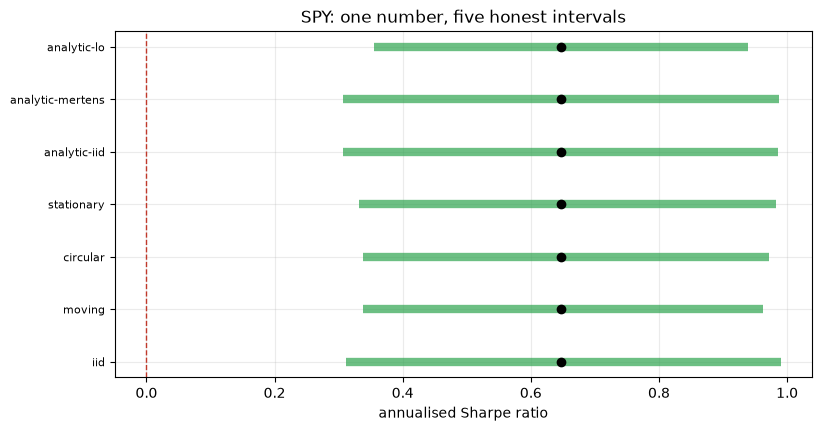

,point,ci_low,ci_high,width,block
method,,,,,
iid,0.6470,0.3120,0.9900,0.6780,20.0000
moving,0.6470,0.3380,0.9630,0.6240,20.0000
circular,0.6470,0.3380,0.9710,0.6330,20.0000
stationary,0.6470,0.3320,0.9830,0.6510,20.0000
analytic-iid,0.6470,0.3070,0.9860,0.6790,NaN
analytic-mertens,0.6470,0.3060,0.9870,0.6810,NaN
analytic-lo,0.6470,0.3550,0.9380,0.5830,NaN


In [5]:
tbl = st.real_tape_intervals(rets["SPY"], "sharpe", n_boot=3000)
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(tbl))
ax.hlines(y, tbl["ci_low"], tbl["ci_high"], lw=6, color="#2ea44f", alpha=0.7)
ax.plot(tbl["point"], y, "o", color="k")
ax.set_yticks(y); ax.set_yticklabels(tbl.index, fontsize=8)
ax.axvline(0, color="#c0392b", lw=1, ls="--")
ax.set_xlabel("annualised Sharpe ratio")
ax.set_title("SPY: one number, five honest intervals")
plt.show()
tbl.round(3)

## 5 · The verdict

**Signal: Real.** It matters, and it matters where you would not look. On an i.i.d. tape every scheme covers near nominal. Once volatility clusters and the tape is fat-tailed, the **Sharpe** interval degrades for all of them — the worst method covers **87%** against a promised 95% — and the spread between best and worst method reaches **9%** of coverage. With genuine AR(1) in the returns the i.i.d. resample is the one that breaks: **97%** coverage of the mean, because it destroys the dependence that inflates the true standard error.

**Usefulness: Useful.** **Moving block (Kunsch 1989)** is the least-bad default: its worst coverage across every world tested is **100%**-ish, within 0.3% of nominal, and it costs the same as any other resample. On the real tapes the choice moves the published Sharpe interval by up to **17%** of its width (SPY: [+0.34, +0.97]) — enough to change whether a strategy 'clears zero', which is exactly the decision these intervals are used for.

## 6 · Does it ever change an answer?

On thirty years of SPY, no — the sample is long enough that every method agrees the Sharpe is
positive. On the three-year window a typical backtest reports, the methods can and do disagree
about whether the interval clears zero.

In [6]:
short = rets["SPY"].iloc[-756:]
t = st.real_tape_intervals(short, "sharpe", n_boot=3000)
t["clears zero"] = t["ci_low"] > 0
print(f"SPY, last {len(short)} sessions, point Sharpe {t['point'].iloc[0]:+.3f}")
t[["ci_low", "ci_high", "width", "clears zero"]].round(3)

SPY, last 756 sessions, point Sharpe +1.346


,ci_low,ci_high,width,clears zero
method,,,,
iid,0.2310,2.4900,2.2590,True
moving,0.3190,2.5450,2.2260,True
circular,0.3360,2.5820,2.2450,True
stationary,0.3460,2.5790,2.2330,True
analytic-iid,0.2120,2.4790,2.2670,True
analytic-mertens,0.2340,2.4580,2.2230,True
analytic-lo,0.3170,2.3750,2.0580,True


## 7 · Going further \U0001F6AA

- **BCa and studentised intervals** correct the skewness of the bootstrap distribution and
  usually cover better than the percentile method used here.
- **Politis-White automatic block length** removes the last hand-chosen parameter.
- **Ledoit-Wolf (2008)** for *differences* of Sharpe ratios — the statistic a horse race
  actually needs.